In [1]:
!git clone https://github.com/hoangquan1503/Walmart_sales_forecasting.git

Cloning into 'Walmart_sales_forecasting'...
remote: Enumerating objects: 54, done.
remote: Counting objects: 100% (54/54), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 54 (delta 16), reused 52 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (54/54), 10.08 KiB | 10.08 MiB/s, done.
Resolving deltas: 100% (16/16), done.


In [2]:
%cd Walmart_sales_forecasting
!git pull

/content/Walmart_sales_forecasting
Already up to date.


: 

: 

In [3]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import numpy as np
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter


# Set the path to the file you'd like to load


# Load the latest version
train = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "aslanahmedov/walmart-sales-forecast",
  "train.csv",
)
stores = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "aslanahmedov/walmart-sales-forecast",
  "stores.csv",
)
features = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "aslanahmedov/walmart-sales-forecast",
  "features.csv",
)

df = train.merge(stores, on='Store').merge(features, on=['Store', 'Date'])

print("First 5 records:", df.head())

/tmp/ipykernel_422/3181991320.py:13: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  train = kagglehub.load_dataset(


100%|██████████| 2.91M/2.91M [00:00<00:00, 143MB/s]

Extracting zip of train.csv...



/tmp/ipykernel_422/3181991320.py:18: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  stores = kagglehub.load_dataset(


Using Colab cache for faster access to the 'walmart-sales-forecast' dataset.


/tmp/ipykernel_422/3181991320.py:23: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  features = kagglehub.load_dataset(


Using Colab cache for faster access to the 'walmart-sales-forecast' dataset.
First 5 records:    Store  Dept        Date  Weekly_Sales  IsHoliday_x Type    Size  \
0      1     1  2010-02-05      24924.50        False    A  151315   
1      1     1  2010-02-12      46039.49         True    A  151315   
2      1     1  2010-02-19      41595.55        False    A  151315   
3      1     1  2010-02-26      19403.54        False    A  151315   
4      1     1  2010-03-05      21827.90        False    A  151315   

   Temperature  Fuel_Price  MarkDown1  MarkDown2  MarkDown3  MarkDown4  \
0        42.31       2.572        NaN        NaN        NaN        NaN   
1        38.51       2.548        NaN        NaN        NaN        NaN   
2        39.93       2.514        NaN        NaN        NaN        NaN   
3        46.63       2.561        NaN        NaN        NaN        NaN   
4        46.50       2.625        NaN        NaN        NaN        NaN   

   MarkDown5         CPI  Unemployment  

: 

: 

In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df['Date']

,Date
0,2010-02-05
1,2010-02-12
2,2010-02-19
3,2010-02-26
4,2010-03-05
...,...
421565,2012-09-28
421566,2012-10-05
421567,2012-10-12
421568,2012-10-19


: 

: 

In [5]:
from src.data_cleaning import check_missing_value, fill_missing_promote

check_missing_value(df)



,counts,ratio
Store,0,0.000000
Dept,0,0.000000
Date,0,0.000000
Weekly_Sales,0,0.000000
IsHoliday_x,0,0.000000
Type,0,0.000000
Size,0,0.000000
Temperature,0,0.000000
Fuel_Price,0,0.000000
MarkDown1,270889,0.642572


: 

: 

In [6]:
markdown = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
df_filled = fill_missing_promote(df, markdown)

: 

: 

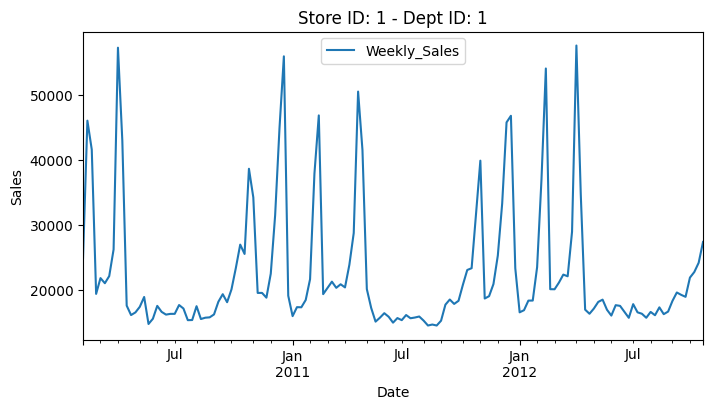

: 

: 

In [7]:
from src.plots import plot_sales

plot_sales(df_filled, 1, 1)

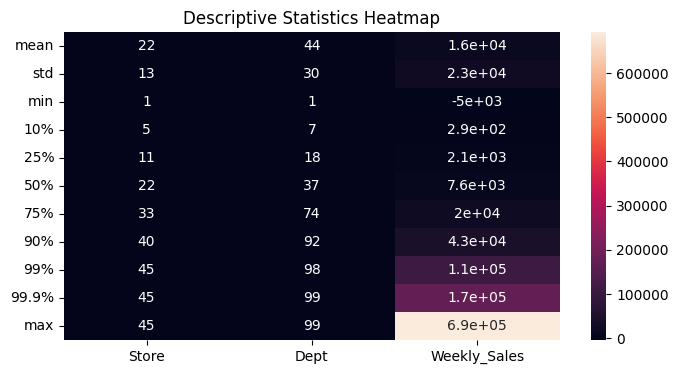

: 

: 

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
summary = (
    df_filled[['Store', 'Dept', 'Weekly_Sales']].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99, 0.999])
    .iloc[1:]
)
plt.figure(figsize=(8, 4)) 
sns.heatmap(summary, cmap='rocket', annot = True)
plt.title("Descriptive Statistics Heatmap")
plt.show()

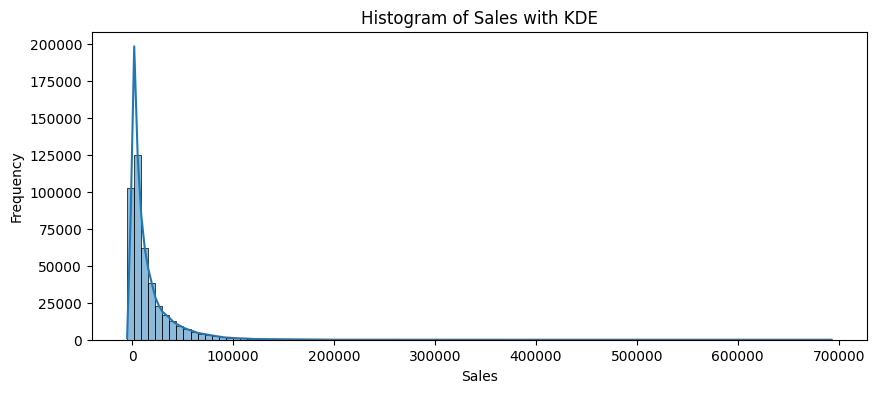

: 

: 

In [17]:
plt.figure(figsize=(10,4))
sns.histplot(df_filled['Weekly_Sales'], bins=100, kde=True)
plt.title('Histogram of Sales with KDE')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

as we can see, there are outliers in this dataset

In [ ]:
from src.data_cleaning import corrected_outlier
df_corrected = corrected_outlier(df_filled)

: 

: 